# 树结构

树，都是树！

# 树处理

In [1]:
class Tree:
    def __init__(self, label, branches=[]):
        self.label = label
        for branch in branches:
            assert isinstance(branch, Tree)
        self.branches = list(branches)
        
    def __repr__(self):
        if self.branches:
            branch_str = ', ' + repr(self.branches)
        else:
            branch_str = ''
        return f'Tree({repr(self.label)}{branch_str})'
        
    def __str__(self):
        return '\n'.join(self.indented())

    def indented(self):
        '''生成标签的缩进表示'''
        '''
        >>> t = Tree('a', [Tree('b'), Tree('c', [Tree('d')])])
        >>> indented(t)
        ['a', '  b', '  c', '    d']
        '''
        lines = []
        for b in self.branches: #遍历所有分支
            for line in b.indented(): 
                lines.append('  ' + line)
        return [str(self.label)] + lines
    
    def is_leaf(self):
        return not self.branches

实现一个函数，返回标签比祖先节点大的节点的个数

首先我们考虑问题的宏观结构：例如判断该节点是否为叶子结点，不是则递归

我们首先否定第一种，因为我们每次递归都要取一个树的分支，这直接导致了祖先节点的标签消失了，没有信息量来求

为了满足这一个信息量，我们必须主动存储节点标签。这告诉我们另一种模式——如果原递归函数的参数列表中不包含足够的信息量，我们就需要在内部写一个helper函数

In [2]:
def bigs(t):
    def f(a, x):
        if a.label > x:
            return 1 + sum([f(b, a.label) for b in a.branches])
        else:
            return sum([f(b, x) for b in a.branches])
    return f(t, t.label - 1)

In [5]:
t=Tree(3,[Tree(1),
        Tree(2,[Tree(1),
                Tree(1)])])

In [6]:
bigs(t)

1

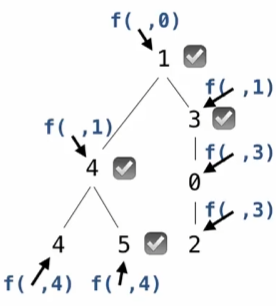